In [1]:
#importing basic libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns" ,None)
pd.set_option("display.float_format" , "{:.2f}".format)

In [2]:
#Importing data

df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\KaggleV2-May-2016.csv")

print(df.shape)
print(df.dtypes)
df.head()

(110527, 14)
PatientId         float64
AppointmentID       int64
Gender                str
ScheduledDay          str
AppointmentDay        str
Age                 int64
Neighbourhood         str
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show               str
dtype: object


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,29872499824296.00,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438.00,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951.00,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174.00,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183.00,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


-  ### Column description

| Columns | Describtion |
| ------- | ----------- |
|**PatientId**      |  Unique ID for each patient (one patient can have many appointments)
|**AppointmentID**  | Unique ID for each appointment
|**Gender**         | F or M
|**ScheduledDay**   | When the patient called to book the appointment
|**AppointmentDay** | The actual day of the appointment
|**Age**            | Patient age
|**Neighbourhood**  | Which area of the city the clinic is in
|**Scholarship**    | 1 = patient is enrolled in Brazil's welfare program (Bolsa Família)
|**Hipertension**   | 1 = patient has hypertension
|**Diabetes**       | 1 = patient has diabetes
|**Alcoholism**     | 1 = patient has alcoholism
|**Handcap**        | 0-4 (number of disabilities — should be 0 or 1)
|**SMS_received**   | 1 = patient got an SMS reminder
|**No-show**        | "Yes" = patient DID NOT show up, "No" = patient showed up

In that time, our agenda is to ***"Will patiant show up on their appointment or not?"***

So we have three hypotheses  
- **H1**  : Patients who did not receive SMS reminder have higher no-show rate
- **H2**  : Longer wait days = higher no-show rate  
- **H3**  : Certain neighbourhoods have higher no-show rates due to distance/transport issues

In [3]:
df = df.rename(columns={
    "Hipertension" : "Hypertension",
    "Handcap" : "Handicap",
    "No-show" : "No_show"
})

print(df.columns.tolist())
    

['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_show']


In [4]:
#Fix the datatype

df["ScheduledDay"] =pd.to_datetime(df["ScheduledDay"], utc = True)
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"], utc = True)

print(df["ScheduledDay"].dtypes)
print(df["AppointmentDay"].dtypes)

datetime64[us, UTC]
datetime64[us, UTC]


In [5]:
#Age problem

print("-1 ages : ", (df["Age"] == -1).sum())  
print("age is > 100 : ",  (df["Age"] > 100).sum())
print("Min age : ", df["Age"].min())
print("Max age : ", df["Age"].max())

-1 ages :  1
age is > 100 :  7
Min age :  -1
Max age :  115


In [6]:
#Fix -1 age with median

median_age = df["Age"].median()
print("Median age = ",median_age)

df.loc[df["Age"] == -1 , "Age"] = median_age
df["Age"] = df["Age"].astype(int)

if (df["Age"] == -1).sum() >= 1: 
    print(" -1 is still in dataset") 
else:
    print(f"-1 is replace with median age = {int(median_age)}") 

print(f"Now age range is from {df['Age'].min()} to {df['Age'].max()}")

Median age =  37.0
-1 is replace with median age = 37
Now age range is from 0 to 115


In [7]:
#Handicap vaule problme

print(df["Handicap"].value_counts())

Handicap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64


- Here we assume that 2, 3 or 4 shows severity or count of disability but for EDA and prediction *"does handicap affect the noshow rate is more useful then how much disability they have"* so we convert it into 0 means no disability and 1 means disability

In [8]:

#Convert Handicap vaule

df['Handicap'] = (df['Handicap'] >= 1).astype(int)

if len(df["Handicap"].value_counts()) == 2:
    print(" 0 shows no disability and 1 shows disability")
else:
    print("dataset still have more than binary vaule")

 0 shows no disability and 1 shows disability


- In no_show column we have str vulue it may misleading or confusing, also it affects in ML model cause we need only number in dataset 

- So we change it into binary format in which 0 means showd up and 1 means didn't showes up

In [9]:
df["No_show"] = (df["No_show"] == "Yes").astype(int)

In [10]:
df["No_show"].value_counts()

No_show
0    88208
1    22319
Name: count, dtype: int64

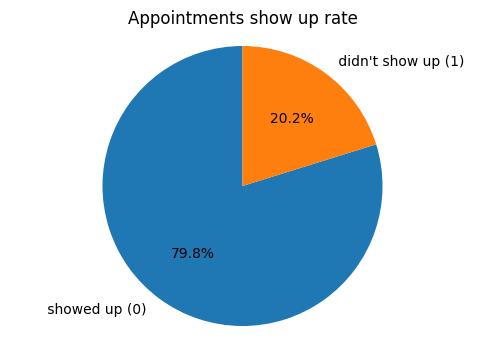

In [11]:
#visualize the No_show with pie chart

plt.figure(figsize=(6,4))
plt.pie((df["No_show"].value_counts()),labels =[ " showed up (0) " , " didn't show up (1) " ], autopct = "%1.1f%%" , startangle = 90)
plt.title("Appointments show up rate")
plt.axis("equal")
plt.show()

In [12]:
#So now we cheak our 2nd hypothesis first and for that we do feature enginnering and add some new column

df["wait_day"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days

print(df["wait_day"].describe())
print()
print("Negitive wait days : ",(df["wait_day"] < 0).sum())

count   110527.00
mean         9.18
std         15.25
min         -7.00
25%         -1.00
50%          3.00
75%         14.00
max        178.00
Name: wait_day, dtype: float64

Negitive wait days :  38568


- As we can see their are 25% vaule with -1 and 38k value is negative this is not small number.
- As we can see in the AppointmentDay column all the time is 00:00:00 means all the appointments have no time they stored at mid-night.
- So for -1 and -2 is time stripping issue so change this vaule with 0.
- And for <-2 vaule, practically this is a data entry error bacause no one can get appointments before scheduled day.
- So for <-2 we assume this data shuffled, and we just swap them(remove negative sign).

In [13]:
#Fix the new column problem

df.loc[df["wait_day"].between(-2,-1) , "wait_day"] = 0

df.loc[df["wait_day"] < -2 , "wait_day"] = df.loc[df["wait_day"] < -2 , "wait_day"].abs()

print(df["wait_day"].describe())
print("Negative wait days : " , (df["wait_day"] < 0).sum())

count   110527.00
mean         9.53
std         15.03
min          0.00
25%          0.00
50%          3.00
75%         14.00
max        178.00
Name: wait_day, dtype: float64
Negative wait days :  0


- Now we have two hypothesis
- **1st** : Weekday → do patients skip Friday appointments more? 
          (long weekend coming, they forget)
- **2nd** : Hour    → do evening bookings (5-6pm) have more no-shows?
          (booked impulsively after work, forget by appointment day)

In [14]:
#Add two more feature

df["appt_weekday"] = df["AppointmentDay"].dt.dayofweek

df["scheduled_hour"] = df["ScheduledDay"].dt.hour

df[['AppointmentDay', 'appt_weekday', 'ScheduledDay', 'scheduled_hour']].head()

,AppointmentDay,appt_weekday,ScheduledDay,scheduled_hour
0,2016-04-29 00:00:00+00:00,4,2016-04-29 18:38:08+00:00,18
1,2016-04-29 00:00:00+00:00,4,2016-04-29 16:08:27+00:00,16
2,2016-04-29 00:00:00+00:00,4,2016-04-29 16:19:04+00:00,16
3,2016-04-29 00:00:00+00:00,4,2016-04-29 17:29:31+00:00,17
4,2016-04-29 00:00:00+00:00,4,2016-04-29 16:07:23+00:00,16


In [15]:
#Last feature 

df["age_groups"] = pd.cut(df["Age"],bins=[0,12,17,35,60,float("inf")],labels=["Child","Teenager","Young Adult","Middle Aged","Senior"]
                          ,include_lowest=True)

In [16]:
print(df['age_groups'].value_counts())
print(df['age_groups'].isnull().sum())

age_groups
Middle Aged    37762
Young Adult    25624
Child          21036
Senior         19762
Teenager        6343
Name: count, dtype: int64
0


In [17]:
# Final cleaning summary
print('Shape:', df.shape)
print('Dtypes:\n', df.dtypes)
print('Nulls:\n', df.isnull().sum())
print('Negative wait day:', (df['wait_day'] < 0).sum())
print('Columns:', df.columns.tolist())

Shape: (110527, 18)
Dtypes:
 PatientId                     float64
AppointmentID                   int64
Gender                            str
ScheduledDay      datetime64[us, UTC]
AppointmentDay    datetime64[us, UTC]
Age                             int64
Neighbourhood                     str
Scholarship                     int64
Hypertension                    int64
Diabetes                        int64
Alcoholism                      int64
Handicap                        int64
SMS_received                    int64
No_show                         int64
wait_day                        int64
appt_weekday                    int32
scheduled_hour                  int32
age_groups                   category
dtype: object
Nulls:
 PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hypertension      0
Diabetes          0
Alcoholism        0
Handicap          0
SMS_received      0
No_sh